# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [2]:
train = pd.read_csv('Iris.csv')
train.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Exploratory Data Analysis

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
d = train.describe()
d

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


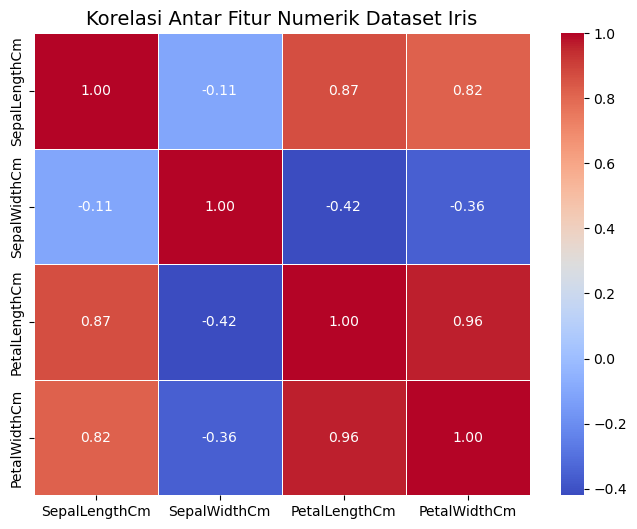

In [5]:
# Memilih hanya kolom numerik untuk korelasi
numeric_train = train.select_dtypes(include=['float64', 'int64']).drop('Id', axis=1, errors='ignore')
corr_matrix = numeric_train.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Antar Fitur Numerik Dataset Iris', fontsize=14)
plt.show()

C:\Users\MadVOST\AppData\Local\Temp\ipykernel_14264\939761327.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species',data=train,palette='RdBu_r')


<Axes: xlabel='Species', ylabel='count'>

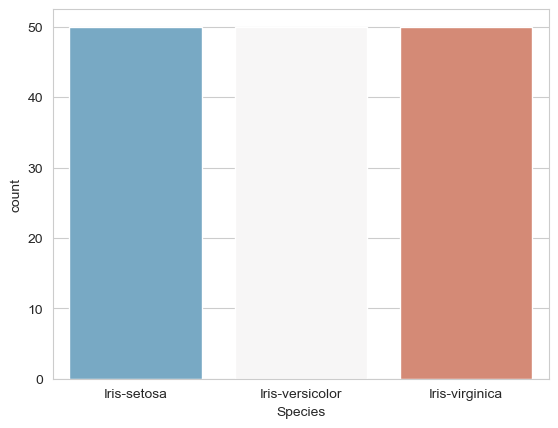

In [6]:
# Cek relative size dari species
sns.set_style('whitegrid')
sns.countplot(x='Species',data=train,palette='RdBu_r')

C:\Users\MadVOST\AppData\Local\Temp\ipykernel_14264\939761327.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species',data=train,palette='RdBu_r')


<Axes: xlabel='Species', ylabel='count'>

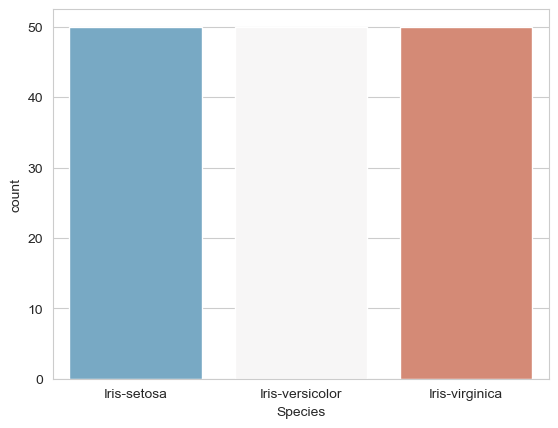

In [7]:
# Cek relative size dari species
sns.set_style('whitegrid')
sns.countplot(x='Species',data=train,palette='RdBu_r')

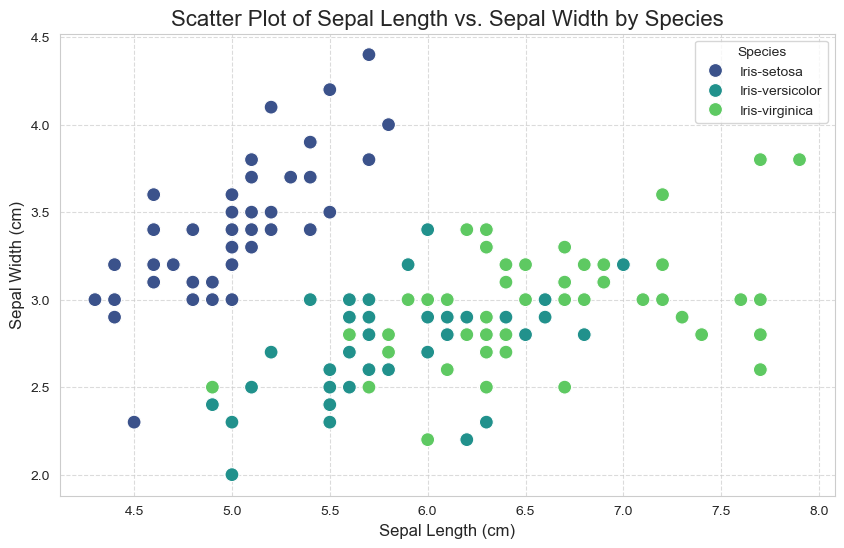

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', hue='Species', data=train, palette='viridis', s=100)
plt.title('Scatter Plot of Sepal Length vs. Sepal Width by Species', fontsize=16)
plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Sepal Width (cm)', fontsize=12)
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

C:\Users\MadVOST\AppData\Local\Temp\ipykernel_14264\1137761745.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species',data=train,palette='rainbow')


<Axes: xlabel='Species', ylabel='count'>

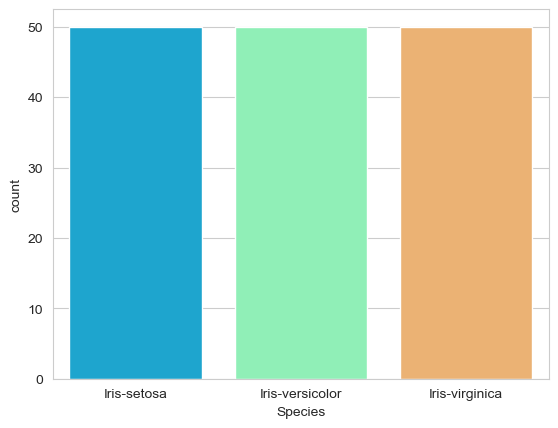

In [9]:
# Cek relative size dari species
sns.set_style('whitegrid')
sns.countplot(x='Species',data=train,palette='rainbow')

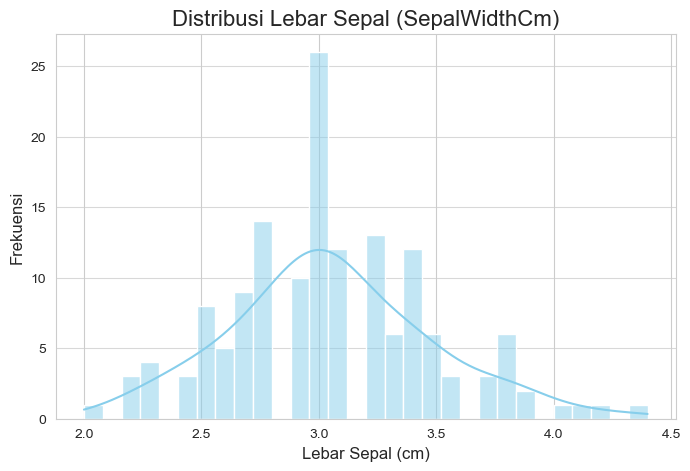

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(train['SepalWidthCm'], kde=True, bins=30, color='skyblue')
plt.title('Distribusi Lebar Sepal (SepalWidthCm)', fontsize=16)
plt.xlabel('Lebar Sepal (cm)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

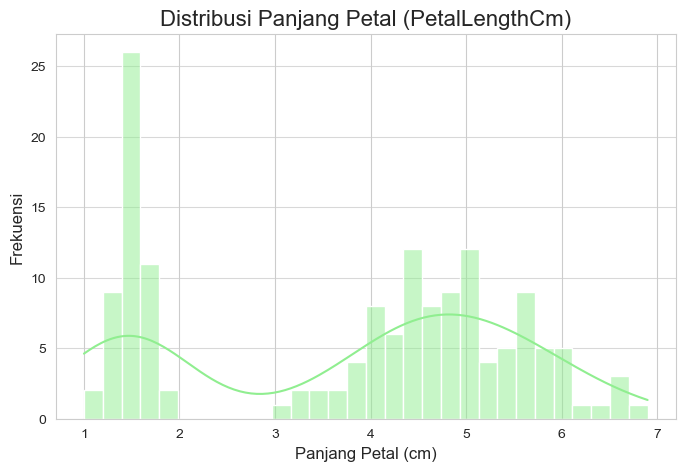

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(train['PetalLengthCm'], kde=True, bins=30, color='lightgreen')
plt.title('Distribusi Panjang Petal (PetalLengthCm)', fontsize=16)
plt.xlabel('Panjang Petal (cm)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

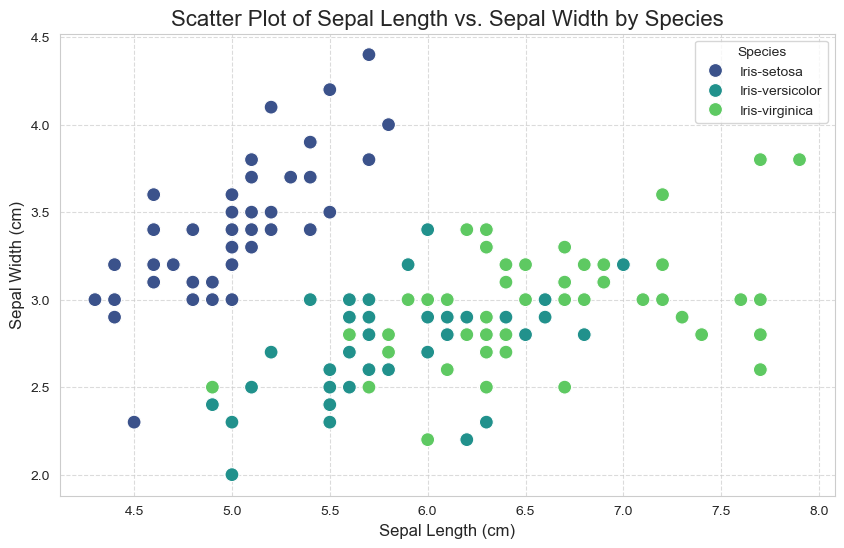

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', hue='Species', data=train, palette='viridis', s=100)
plt.title('Scatter Plot of Sepal Length vs. Sepal Width by Species', fontsize=16)
plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Sepal Width (cm)', fontsize=12)
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [13]:
# Menampilkan 5 baris pertama dataset Iris yang sedang digunakan
print("Dataset Iris yang aktif:")
display(train.head())

# Menampilkan informasi fitur
print("\nInformasi Dataset:")
train.info()

Dataset Iris yang aktif:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [14]:
# Menampilkan daftar kolom yang tersedia
print("Kolom yang tersedia di DataFrame 'train':")
print(train.columns.tolist())

# Menampilkan info lengkap DataFrame
train.info()

Kolom yang tersedia di DataFrame 'train':
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


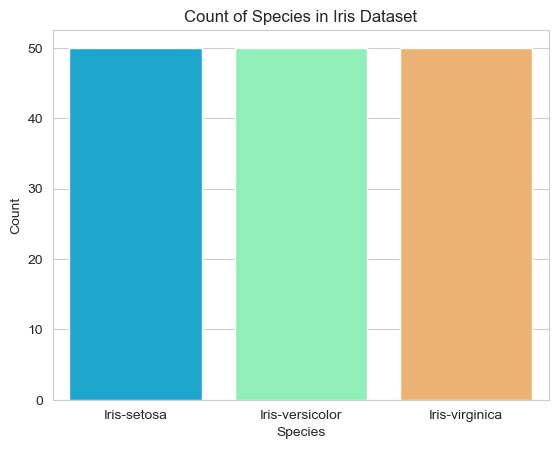

In [15]:
# Example of an analysis adapted for the Iris dataset:
# If you want to visualize the count of species, for instance:
sns.set_style('whitegrid')
sns.countplot(x='Species',data=train,hue='Species',palette='rainbow', legend=False)
plt.title('Count of Species in Iris Dataset')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

In [16]:


print("Kolom yang tersedia di dataset ini adalah:", train.columns.tolist())

Kolom yang tersedia di dataset ini adalah: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


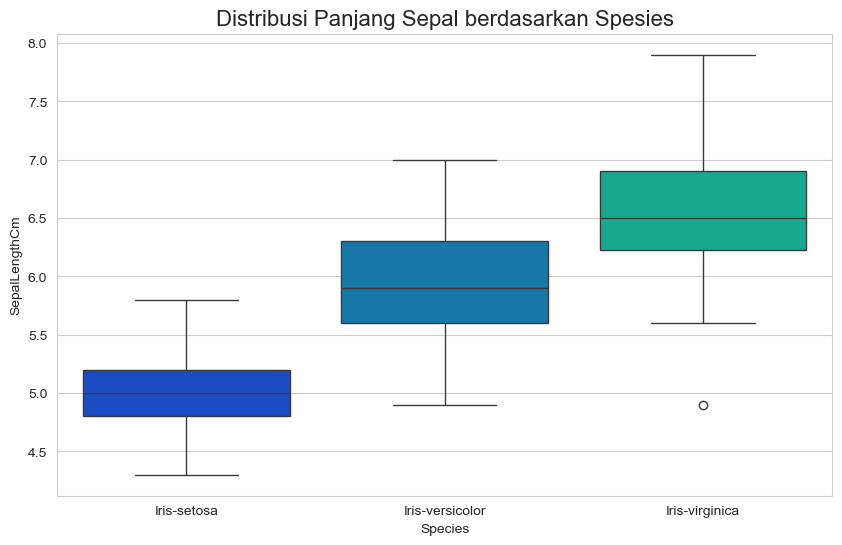

In [17]:
# Contoh visualisasi yang sesuai untuk dataset Iris:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Species', y='SepalLengthCm', data=train, palette='winter', hue='Species', legend=False)
plt.title("Distribusi Panjang Sepal berdasarkan Spesies", fontsize=16)
plt.show()

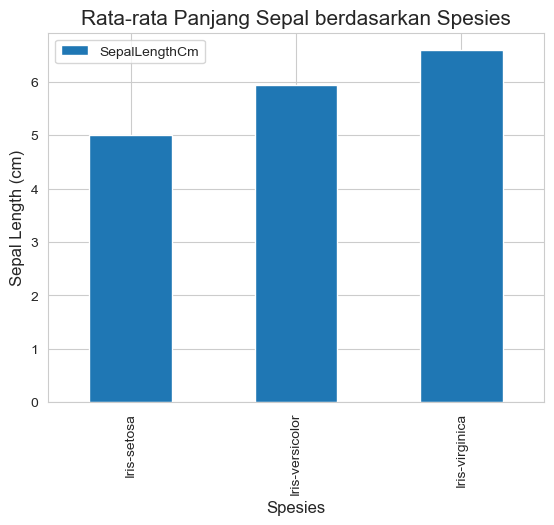

In [18]:
f_species_Sepal = train.groupby('Species')['SepalLengthCm'].mean()
f_species_Sepal = pd.DataFrame(f_species_Sepal)
f_species_Sepal.plot.bar(y='SepalLengthCm')
plt.title("Rata-rata Panjang Sepal berdasarkan Spesies", fontsize=15)
plt.ylabel("Sepal Length (cm)", fontsize=12)
plt.xlabel("Spesies", fontsize=12)
plt.show()

### Fitur Engineering

In [19]:
print("Kolom yang ada di dataset Iris:", train.columns.tolist())




Kolom yang ada di dataset Iris: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [20]:
print("Tahap imputasi dilewati karena dataset Iris tidak memerlukan pembersihan kolom 'Age' atau 'Pclass'.")

Tahap imputasi dilewati karena dataset Iris tidak memerlukan pembersihan kolom 'Age' atau 'Pclass'.


Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

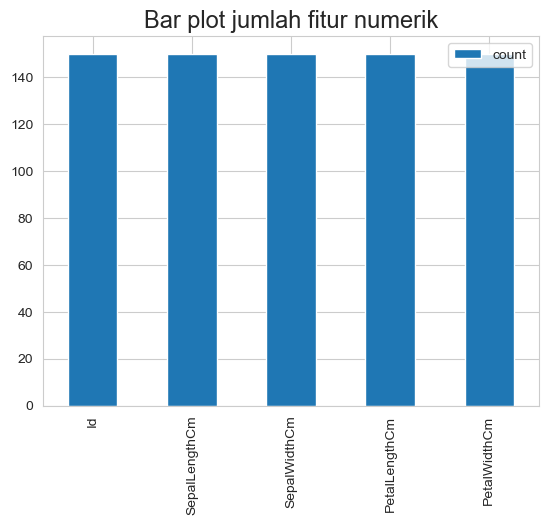

In [21]:
d=train.describe()
dT=d.T
dT.plot.bar(y='count')
plt.title("Bar plot jumlah fitur numerik",fontsize=17)

In [22]:

print("Kolom yang tersedia:", train.columns.tolist())
print("\nLangkah penghapusan kolom 'Cabin' dilewati karena tidak relevan dengan dataset Iris.")

Kolom yang tersedia: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Langkah penghapusan kolom 'Cabin' dilewati karena tidak relevan dengan dataset Iris.


In [23]:
# Error: KeyError karena kolom Titanic ('PassengerId', 'Name', 'Ticket') tidak ada di dataset Iris.
# Di dataset Iris, kita hanya perlu menghapus kolom 'Id'.

if 'Id' in train.columns:
    train.drop('Id', axis=1, inplace=True)
    print("Kolom 'Id' berhasil dihapus.")
else:
    print("Kolom 'Id' tidak ditemukan atau sudah dihapus.")

train.head()

Kolom 'Id' berhasil dihapus.


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [24]:
from sklearn.preprocessing import LabelEncoder

# Menggunakan LabelEncoder untuk kolom 'Species' di dataset Iris
le = LabelEncoder()
train['Species'] = le.fit_transform(train['Species'])

# Menampilkan hasil encoding (0: Iris-setosa, 1: Iris-versicolor, 2: Iris-virginica)
print("Mapping Species:", dict(zip(le.classes_, le.transform(le.classes_))))
train.head()

Mapping Species: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Training

In [25]:
from sklearn.model_selection import train_test_split

# Menggunakan 'Species' sebagai target (y) dan kolom lainnya sebagai fitur (X)
X = train.drop('Species', axis=1)
y = train['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("Data berhasil dipisahkan menjadi training dan testing set.")

Data berhasil dipisahkan menjadi training dan testing set.


In [26]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (105, 4)
Test shape: (45, 4)


# **KNN**

In [27]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [28]:
y_pred = clf1.predict(X_test)

### Evaluation

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [30]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika ingin mencoba semua parameter

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.942857   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.942857   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.942857   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.942857   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.942857   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.942857   
11  {'metric': 'manhattan', 'n_neighbors

In [33]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [34]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}


In [35]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  1.00
Presisi:  1.00
Recall:   1.00
F1-Score: 1.00

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [36]:
import numpy as np

# Data bunga baru (4 fitur: SepalLength, SepalWidth, PetalLength, PetalWidth)
# Contoh: bunga dengan ukuran 5.1, 3.5, 1.4, 0.2
new_data = np.array([[5.1, 3.5, 1.4, 0.2]])

# Prediksi spesies bunga
prediction = best_model.predict(new_data)

# Mapping label kembali ke nama spesies
species_mapping = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}
print(f"Hasil Prediksi: {prediction[0]} ({species_mapping[prediction[0]]})")

Hasil Prediksi: 0 (Iris-setosa)


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
